2026-05-15 12:00:49.000870: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778846449.204796      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778846449.265385      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778846449.749175      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778846449.749213      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778846449.749216      57 computation_placer.cc:177] computation placer alr

=== 1. 基础设置与自动寻找路径 ===
✅ 成功找到训练集路径: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train
✅ 成功找到测试集路径: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test
=== 1. 数据准备与加载 ===
Found 5216 files belonging to 2 classes.
Using 4173 files for training.


I0000 00:00:1778846485.202032      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778846485.207865      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.
类别名称: ['NORMAL', 'PNEUMONIA']

=== 2. 模型构建 (自定义 CNN) ===

=== 3. 模型训练 ===
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1778846513.007703     138 cuda_dnn.cc:529] Loaded cuDNN version 91002


131/131 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.4474 - loss: 0.6929 - val_accuracy: 0.8073 - val_loss: 0.4584
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8707 - loss: 0.3359 - val_accuracy: 0.8869 - val_loss: 0.2718
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8904 - loss: 0.2594 - val_accuracy: 0.8226 - val_loss: 0.4125
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9061 - loss: 0.2243 - val_accuracy: 0.9099 - val_loss: 0.2127
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9230 - loss: 0.1841 - val_accuracy: 0.9348 - val_loss: 0.1646
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9311 - loss: 0.1672 - val_accuracy: 0.9444 - val_loss: 0.1551
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9288 - loss: 0.1669 - val_accuracy: 0.9511 - val_loss: 0.1209
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9355 - loss: 0.1609 - val_accuracy: 0.92

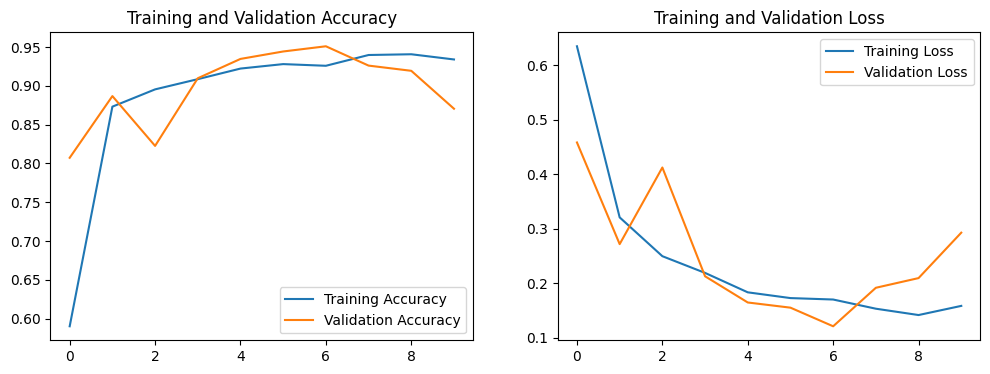

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

[Test Set Metrics]
Accuracy : 0.8830
Precision: 0.9204
Recall   : 0.8897
F1 Score : 0.9048

Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.83      0.87      0.85       234
   PNEUMONIA       0.92      0.89      0.90       390

    accuracy                           0.88       624
   macro avg       0.87      0.88      0.88       624
weighted avg       0.88      0.88      0.88       624



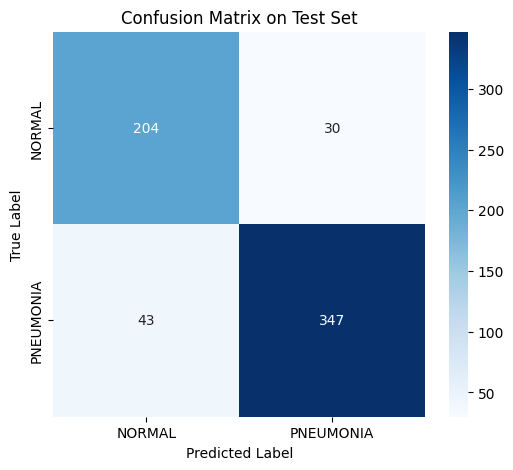

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("=== 1. 基础设置与自动寻找路径 ===")
# 终极自动寻路：在整个 Kaggle input 目录里自动搜索真实的 train 文件夹
train_dir = ""
test_dir = ""
for root, dirs, files in os.walk('/kaggle/input'):
    if 'train' in dirs:
        potential_train = os.path.join(root, 'train')
        # 确认这个 train 文件夹里面真的有 NORMAL 类别图片
        if os.path.exists(os.path.join(potential_train, 'NORMAL')):
            train_dir = potential_train
            test_dir = os.path.join(root, 'test')
            break

print(f"✅ 成功找到训练集路径: {train_dir}")
print(f"✅ 成功找到测试集路径: {test_dir}")

figures_dir = './figures'
os.makedirs(figures_dir, exist_ok=True)

BATCH_SIZE = 32
IMG_SIZE = (150, 150)
EPOCHS = 10

print("=== 1. 数据准备与加载 ===")
# 使用 image_dataset_from_directory 按 8:2 划分训练集和验证集
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # 测试集不要打乱，方便后续算指标
)

class_names = train_dataset.class_names
print(f"类别名称: {class_names}") # ['NORMAL', 'PNEUMONIA']

# 为了提高性能，使用 prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("\n=== 2. 模型构建 (自定义 CNN) ===")
# 数据增强层
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Flatten(),
    layers.Dropout(0.5), # 缓解过拟合
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid') # 二分类
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 计算类别权重 (处理类别不平衡: Pneumonia 远多于 Normal)
# 训练集中 Normal 大约 1341 张，Pneumonia 大约 3875 张 (总数 5216)
weight_for_0 = (1 / 1341) * (5216 / 2.0)
weight_for_1 = (1 / 3875) * (5216 / 2.0)
class_weight = {0: weight_for_0, 1: weight_for_1}

print("\n=== 3. 模型训练 ===")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=class_weight
)

print("\n=== 4. 模型评估与结果绘制 ===")
# 绘制 Loss 和 Accuracy 曲线
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.savefig(os.path.join(figures_dir, 'training_curves.png'))
plt.show()

# 在测试集上进行预测
y_true = []
for images, labels in test_dataset.unbatch():
    y_true.append(labels.numpy())
y_true = np.array(y_true)

predictions = model.predict(test_dataset)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# 计算各项指标 (宏观/针对Pneumonia类)
acc_score = accuracy_score(y_true, y_pred)
prec_score = precision_score(y_true, y_pred)
rec_score = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"\n[Test Set Metrics]")
print(f"Accuracy : {acc_score:.4f}")
print(f"Precision: {prec_score:.4f}")
print(f"Recall   : {rec_score:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# 绘制混淆矩阵
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.savefig(os.path.join(figures_dir, 'confusion_matrix.png'))
plt.show()